<a href="https://colab.research.google.com/github/jcarlosfelix/jupyter_notebook/blob/main/Taller_Practico_Preprocesamiento_de_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TecNM / Instituto Tecnológico de Tijuana
## Materia: Analítica de Datos (IAD-2403)
### Profesor: José Carlos Félix Saúl
---
# Taller Práctico: Preprocesamiento de Datos - Muestreo y Cuantificación

**Objetivos de la sesión:**
1. Importar y explorar datasets estructurados usando `pandas`.
2. Aplicar filtrados condicionales.
3. Realizar limpieza de información anómala o nula mediante funciones `lambda` y `.apply()`.
4. Cuantificar datos categóricos (Label Encoding, Ordinal Encoding y One-Hot Encoding).
5. Experimentar con distintas técnicas de muestreo en Pandas (Aleatorio Simple, Estratificado y Sistemático).
6. Generar visualizaciones descriptivas para comparar muestras contra la población total.

### [Código 1: Importación de Librerías]

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Configuración gráfica para el taller
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

print("Librerías cargadas exitosamente.")

Librerías cargadas exitosamente.


## Parte 1: Carga de Datos y Exploración Inicial
Cargamos el archivo CSV del taller y realizamos una inspección de la estructura, tipos de datos y primeros registros.

### [Código 2: Carga de Dataset]

In [ ]:
# Carga del dataset CSV del concentrado de información de la clase
archivo_csv = 'Actividad_Taller-Concentrado_Info.csv'

# Intentamos cargar el archivo especificando codificación estándar
try:

    #df = pd.read_csv(archivo_csv)
    df = pd.read_csv(archivo_csv, encoding='latin1')

    print(f"Dataset cargado correctamente. Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas.")
except FileNotFoundError:
    print("Asegúrate de que el archivo CSV se encuentra en la misma carpeta que este Notebook.")

# Muestra general
df.head()

Dataset cargado correctamente. Dimensiones: 22 filas x 24 columnas.


,No.,ID / Nombre u Alias,Linux,Git / GitHub,Empleo,SQL,Café / Energizante,Transporte Propio,Edad,Estatura (cm),...,Municipio,Nivel Python,Entusiasmo IA,Álgebra / Cálculo,Videojuegos,Ciencia de Datos,Robótica / Hardware,Web / Apps,Fecha de Captura,Unnamed: 23
0,1,Osnay,No,Sí,No,Sí,No,No,19,160,...,Tijuana,Principiante,Alto,Mucho,Mucho,Medio,Encanta,Encanta,N/D,NaN
1,2,Guille,No,Sí,No,Sí,No,Sí,19,155,...,Tijuana,Principiante,Alto,Poco,Mucho,Medio,Mucho,Mucho,N/D,NaN
2,3,Melanny,No,Sí,No,Sí,No,No,18,145,...,Tecate,Principiante,Alto,Poco,Poco,Nada,Mucho,Nada,N/D,NaN
3,4,Win,Sí,Sí,No,Sí,Sí,No,19,187,...,Tijuana,Intermedio,Alto,Medio,Poco,Encanta,Medio,Mucho,N/D,NaN
4,5,Jayt,No,Sí,No,Sí,No,No,19,175,...,Tijuana,Principiante,Muy Alto,Medio,Encanta,Medio,Mucho,Mucho,N/D,NaN


### [Código 3: Inspección Estructural]

In [ ]:
# Verificación de tipos de datos y valores nulos
print("--- INFORMACIÓN DEL DATAFRAME ---")
df.info()

print("\n--- RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS ---")
display(df.describe())

print("\n--- PRIMERAS CATEGORÍAS EN VARIABLES DE TEXTO ---")
display(df.describe(include=['O']))

--- INFORMACIÓN DEL DATAFRAME ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   No.                  22 non-null     int64  
 1   ID / Nombre u Alias  22 non-null     object 
 2   Linux                22 non-null     object 
 3   Git / GitHub         22 non-null     object 
 4   Empleo               22 non-null     object 
 5   SQL                  22 non-null     object 
 6   Café / Energizante   22 non-null     object 
 7   Transporte Propio    22 non-null     object 
 8   Edad                 22 non-null     object 
 9   Estatura (cm)        22 non-null     int64  
 10  Traslado (min)       22 non-null     int64  
 11  Estudio (hrs/sem)    22 non-null     object 
 12  Tazas Café (día)     22 non-null     int64  
 13  Lenguaje Preferido   22 non-null     object 
 14  Municipio            22 non-null     object 
 15  Nivel Py

,No.,Estatura (cm),Traslado (min),Tazas Café (día),Unnamed: 23
count,22.000000,22.000000,22.000000,22.000000,0.0
mean,11.500000,168.636364,54.590909,0.818182,NaN
std,6.493587,11.737386,26.857045,1.180652,NaN
min,1.000000,145.000000,6.000000,0.000000,NaN
25%,6.250000,160.250000,32.500000,0.000000,NaN
50%,11.500000,170.500000,55.000000,0.000000,NaN
75%,16.750000,176.500000,75.000000,1.750000,NaN
max,22.000000,187.000000,100.000000,4.000000,NaN



--- PRIMERAS CATEGORÍAS EN VARIABLES DE TEXTO ---


,ID / Nombre u Alias,Linux,Git / GitHub,Empleo,SQL,Café / Energizante,Transporte Propio,Edad,Estudio (hrs/sem),Lenguaje Preferido,Municipio,Nivel Python,Entusiasmo IA,Álgebra / Cálculo,Videojuegos,Ciencia de Datos,Robótica / Hardware,Web / Apps,Fecha de Captura
count,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22
unique,22,3,4,4,4,4,4,7,11,3,3,3,4,4,5,5,6,6,6
top,Osnay,No,Sí,No,Sí,No,No,19,N/D,Python,Tijuana,Principiante,Alto,Mucho,Mucho,Medio,Mucho,Mucho,"Sep, 17. 2026"
freq,1,14,8,11,11,11,9,14,5,20,18,17,13,8,8,8,13,9,6


## Parte 2: Filtrado por Condición
El filtrado por condición permite aislar subconjuntos de interés para análisis específicos (ej. respuestas por rango de edad o ubicación geográfica).

### [Código 4: Ejercicios de Filtrado]

### Identificación de columnas de texto y numéricas para adaptar las consultas automáticamente

In [ ]:
# Identificación de columnas de texto y numéricas para adaptar las consultas automáticamente
col_num = df.select_dtypes(include=[np.number]).columns.tolist()
col_cat = df.select_dtypes(include=['object']).columns.tolist()

### Ejercicio 1: Filtrado numérico (ej. valores superiores al promedio en la primera columna numérica)

In [ ]:
# Ejercicio 1: Filtrado numérico (ej. valores superiores al promedio en la primera columna numérica)
if col_num:
    col_ref_num = col_num[0]
    promedio_val = df[col_ref_num].mean()

    filtro_num = df[df[col_ref_num] > promedio_val]

    print(f"Registros con '{col_ref_num}' superior al promedio ({promedio_val:.2f}): {len(filtro_num)}")
    display(filtro_num.head(3))

Registros con 'No.' superior al promedio (11.50): 11


,No.,ID / Nombre u Alias,Linux,Git / GitHub,Empleo,SQL,Café / Energizante,Transporte Propio,Edad,Estatura (cm),...,Municipio,Nivel Python,Entusiasmo IA,Álgebra / Cálculo,Videojuegos,Ciencia de Datos,Robótica / Hardware,Web / Apps,Fecha de Captura,Unnamed: 23
11,12,Jasiel Said,NO,NO,NO,SI,NO,NO,21,171,...,Tijuana,principiante,Alto,Medio,Poco,Medio,Mucho,Medio,"Sep, 17. 2026",NaN
12,13,Carter,NO,NO,SI,SI,SI,SI,19,170,...,Tijuana,Principiante,Alto,Mucho,Mucho,Mucho,Mucho,Medio,"Sep, 17. 2026",NaN
13,14,Jesus,NO,SI,NO,SI,NO,NO,19,172,...,Tijuana,Principiante,Medio,Poco,Medio,Medio,Mucho,Medio,"Sep, 17. 2026",NaN


### Ejercicio 2: Filtrado por coincidencia categórica

In [ ]:
# Ejercicio 2: Filtrado por coincidencia categórica
if col_cat:
    col_ref_cat = col_cat[0]
    categoria_frecuente = df[col_ref_cat].mode()[0]

    filtro_cat = df[df[col_ref_cat] == categoria_frecuente]

    print(f"\nRegistros filtrados por '{col_ref_cat}' == '{categoria_frecuente}': {len(filtro_cat)}")
    display(filtro_cat.head(3))


Registros filtrados por 'ID / Nombre u Alias' == 'Antonio': 1


,No.,ID / Nombre u Alias,Linux,Git / GitHub,Empleo,SQL,Café / Energizante,Transporte Propio,Edad,Estatura (cm),...,Municipio,Nivel Python,Entusiasmo IA,Álgebra / Cálculo,Videojuegos,Ciencia de Datos,Robótica / Hardware,Web / Apps,Fecha de Captura,Unnamed: 23
9,10,Antonio,No,No,Sí,No,No,No,22,167,...,Playas de Rosarito,Principiante,Alto,Medio,Mucho,Poco,Medio,Mucho,15/08/2026,NaN


## Parte 3: Limpieza de Datos y Uso de Funciones Lambda
Siguiendo las metodologías del taller, procesaremos valores faltantes, registros fuera de rango (como valores negativos o nulos) y estandarizaremos textos.

### [Código 5: Limpieza y Transformación]

In [ ]:
# Copia de trabajo para la limpieza
df_clean = df.copy()

# 1. Estandarización de texto (eliminar espacios en blanco sobrantes y convertir a formato Titulo)
for col in col_cat:
    df_clean[col] = df_clean[col].apply(lambda x: x.strip().title() if isinstance(x, str) else x)

# 2. Corrección/Imputación de valores numéricos incoherentes o nulos mediante lambda[cite: 1]
for col in col_num:
    # Calculamos la media de valores válidos (mayores a cero)[cite: 1]
    media_valida = df_clean[df_clean[col] > 0][col].mean()
    if np.isnan(media_valida):
        media_valida = 0

    # Aplicación de lambda para reemplazar nulos o negativos por la media[cite: 1]
    df_clean[col] = df_clean[col].apply(
        lambda x: media_valida if pd.isnull(x) or (isinstance(x, (int, float)) and x < 0) else x
    )

print("Estado de nulos tras la limpieza:")
print(df_clean.isnull().sum())

Estado de nulos tras la limpieza:
No.                    0
ID / Nombre u Alias    0
Linux                  0
Git / GitHub           0
Empleo                 0
SQL                    0
Café / Energizante     0
Transporte Propio      0
Edad                   0
Estatura (cm)          0
Traslado (min)         0
Estudio (hrs/sem)      0
Tazas Café (día)       0
Lenguaje Preferido     0
Municipio              0
Nivel Python           0
Entusiasmo IA          0
Álgebra / Cálculo      0
Videojuegos            0
Ciencia de Datos       0
Robótica / Hardware    0
Web / Apps             0
Fecha de Captura       0
Unnamed: 23            0
dtype: int64


## Parte 4: Cuantificación de Datos
Convertiremos las variables de texto/categóricas a formatos numéricos aptos para modelos de cómputo y aprendizaje automático:
* **Label Encoding / Mapeo Diccionario:** Asignación de un entero a cada categoría.
* **One-Hot Encoding:** Creación de columnas binarias ($0$ o $1$) por cada categoría.

### [Código 6: Técnicas de Cuantificación]

### Demostración de Label Encoding en columna

In [ ]:
df_cuant = df_clean.copy()

if len(col_cat) > 0:
    # 1. Uso de Map con Diccionario (Label Encoding manual)
    col_target1 = col_cat[0]

    categorias_unicas = df_cuant[col_target1].unique()
    print(categorias_unicas)


['Osnay' 'Guille' 'Melanny' 'Win' 'Jayt' 'Mauricio' 'Madelyne' 'Day'
 'Crisol' 'Antonio' 'Hecthor' 'Jasiel Said' 'Carter' 'Jesus'
 'Halison Melani' 'Jacob' 'Josue' 'Rojo' 'Paloma' 'Rosa' 'Richard' 'Eder']


In [ ]:
    mapa_categorias = {cat: idx + 1 for idx, cat in enumerate(categorias_unicas)}
    print(mapa_categorias)

    df_cuant[f'{col_target1}_Cod_Map'] = df_cuant[col_target1].map(mapa_categorias)

    # 2. LabelEncoder de Scikit-Learn
    le = LabelEncoder()
    df_cuant[f'{col_target1}_Cod_LE'] = le.fit_transform(df_cuant[col_target1])

    print(f"Demostración de Label Encoding en columna '{col_target1}':")
    display(df_cuant[[col_target1, f'{col_target1}_Cod_Map', f'{col_target1}_Cod_LE']].head())

{'Osnay': 1, 'Guille': 2, 'Melanny': 3, 'Win': 4, 'Jayt': 5, 'Mauricio': 6, 'Madelyne': 7, 'Day': 8, 'Crisol': 9, 'Antonio': 10, 'Hecthor': 11, 'Jasiel Said': 12, 'Carter': 13, 'Jesus': 14, 'Halison Melani': 15, 'Jacob': 16, 'Josue': 17, 'Rojo': 18, 'Paloma': 19, 'Rosa': 20, 'Richard': 21, 'Eder': 22}
Demostración de Label Encoding en columna 'ID / Nombre u Alias':


,ID / Nombre u Alias,ID / Nombre u Alias_Cod_Map,ID / Nombre u Alias_Cod_LE
0,Osnay,1,16
1,Guille,2,5
2,Melanny,3,15
3,Win,4,21
4,Jayt,5,10


### Demostración de One-Hot Encoding en columna

In [ ]:
if len(col_cat) > 1:
    # 3. One-Hot Encoding con Pandas[cite: 1]
    col_target2 = col_cat[1]
    df_onehot = pd.get_dummies(df_cuant[col_target2], prefix=col_target2, dtype=int)

    print(f"\nDemostración de One-Hot Encoding en columna '{col_target2}':")
    display(pd.concat([df_cuant[[col_target2]], df_onehot], axis=1).head())


Demostración de One-Hot Encoding en columna 'Linux':


,Linux,Linux_No,Linux_Sí
0,No,1,0
1,No,1,0
2,No,1,0
3,Sí,0,1
4,No,1,0


## Parte 5: Métodos de Muestreo en Pandas
Evaluaremos tres estrategias para seleccionar muestras representativas de la población total:
1. **Muestreo Aleatorio Simple:** Selección sin criterio específico (`df.sample`).
2. **Muestreo Estratificado:** Muestreo proporcional por grupos/estratos.
3. **Muestreo Sistemático:** Selección periódica cada $k$-ésimo elemento.

### [Código 7: Ejecución de Muestreos]

In [ ]:
tamano_población = len(df_clean)
tamano_muestra = max(3, int(tamano_población * 0.3)) # Tomamos ~30% como muestra

print(f"Población total: {tamano_población} registros.")

Población total: 22 registros.


### 1. Muestreo Aleatorio Simple

In [ ]:
# 1. Muestreo Aleatorio Simple
muestra_simple = df_clean.sample(n=tamano_muestra, random_state=42)

print(f"Muestra Aleatoria Simple: {len(muestra_simple)} registros.")
print(muestra_simple)

Muestra Aleatoria Simple: 6 registros.
    No. ID / Nombre u Alias Linux Git / GitHub Empleo SQL Café / Energizante  \
0     1               Osnay    No           Sí     No  Sí                 No   
13   14               Jesus    No           Si     No  Si                 No   
8     9              Crisol    No           No     No  No                 No   
1     2              Guille    No           Sí     No  Sí                 No   
15   16               Jacob    No           No     No  Si                 Si   
5     6            Mauricio    No           No     Sí  Sí                 No   

   Transporte Propio Edad  Estatura (cm)  ...           Municipio  \
0                 No   19            160  ...             Tijuana   
13                No   19            172  ...             Tijuana   
8                 No   19            150  ...             Tijuana   
1                 Sí   19            155  ...             Tijuana   
15                Si   19            180  ...          

### 2. Muestreo Sistemático (tomando cada k-ésimo elemento)

In [ ]:
# 2. Muestreo Sistemático (tomando cada k-ésimo elemento)
k = max(1, tamano_población // tamano_muestra)
muestra_sistemática = df_clean.iloc[::k].head(tamano_muestra)

print(f"Muestra Sistemática (k={k}): {len(muestra_sistemática)} registros.")
print(muestra_sistemática)

Muestra Sistemática (k=3): 6 registros.
    No. ID / Nombre u Alias Linux Git / GitHub Empleo SQL Café / Energizante  \
0     1               Osnay    No           Sí     No  Sí                 No   
3     4                 Win    Sí           Sí     No  Sí                 Sí   
6     7            Madelyne    No           No     Sí  Sí                 Sí   
9    10             Antonio    No           No     Sí  No                 No   
12   13              Carter    No           No     Si  Si                 Si   
15   16               Jacob    No           No     No  Si                 Si   

   Transporte Propio Edad  Estatura (cm)  ...           Municipio  \
0                 No   19            160  ...             Tijuana   
3                 No   19            187  ...             Tijuana   
6                 Sí   19            156  ...             Tijuana   
9                 No   22            167  ...  Playas De Rosarito   
12                Si   19            170  ...         

### 3. Muestreo Estratificado (tomando muestras según una variable categórica)

In [ ]:
# 3. Muestreo Estratificado (tomando muestras según una variable categórica)
if len(col_cat) > 0:
    estrato_col = col_cat[0]
    muestra_estratificada = df_clean.groupby(estrato_col, group_keys=False).apply(
        lambda x: x.sample(frac=0.3, random_state=42) if len(x) > 1 else x
    )
else:
    muestra_estratificada = muestra_simple

print(f"Muestra Estratificada: {len(muestra_estratificada)} registros.")
#print(muestra_estratificada)

Muestra Estratificada: 22 registros.


/tmp/ipykernel_1865/1752600607.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  muestra_estratificada = df_clean.groupby(estrato_col, group_keys=False).apply(


## Parte 6: Visualización de Resultados
Comparamos las distribuciones de la **Población Total** con las de las **Muestras** para analizar la representatividad.

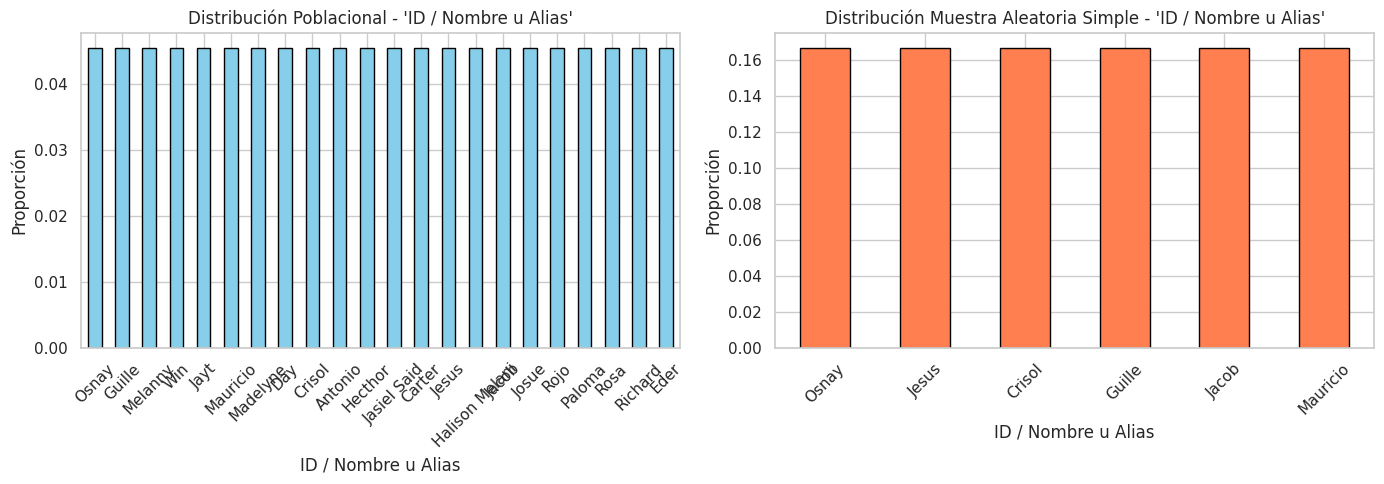

In [ ]:
if len(col_cat) > 0:
    col_vis = col_cat[0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    # Gráfico 1: Población Total
    df_clean[col_vis].value_counts(normalize=True).plot(
        kind='bar', ax=axes[0], color='skyblue', edgecolor='black'
    )
    axes[0].set_title(f"Distribución Poblacional - '{col_vis}'")
    axes[0].set_ylabel("Proporción")
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

    # Gráfico 2: Muestra Estratificada vs Aleatoria
    muestra_simple[col_vis].value_counts(normalize=True).plot(
        kind='bar', ax=axes[1], color='coral', edgecolor='black'
    )
    axes[1].set_title(f"Distribución Muestra Aleatoria Simple - '{col_vis}'")
    axes[1].set_ylabel("Proporción")
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

    plt.tight_layout()
    plt.show()

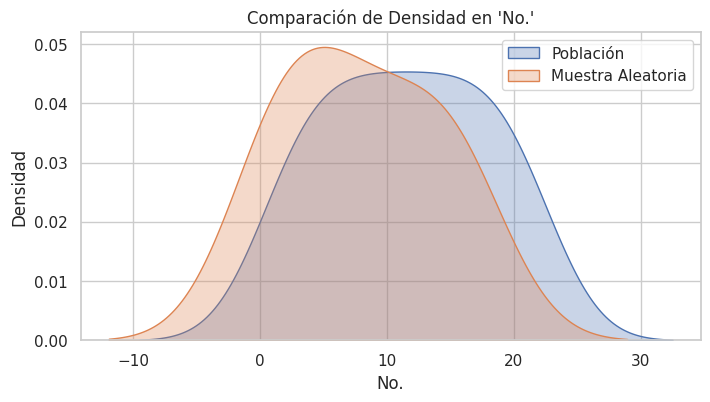

In [ ]:
# Histogramas si existen variables numéricas
if len(col_num) > 0:
    col_num_vis = col_num[0]
    plt.figure(figsize=(8, 4))
    sns.kdeplot(df_clean[col_num_vis], label='Población', fill=True, alpha=0.3)
    sns.kdeplot(muestra_simple[col_num_vis], label='Muestra Aleatoria', fill=True, alpha=0.3)
    plt.title(f"Comparación de Densidad en '{col_num_vis}'")
    plt.xlabel(col_num_vis)
    plt.ylabel("Densidad")
    plt.legend()
    plt.show()

## Parte 7: Preguntas de Reflexión (Para Discusión en Clase)

1. **¿Cuándo es preferible utilizar un muestreo estratificado sobre uno aleatorio simple?**
2. **¿Qué implicaciones o sesgos genera realizar una cuantificación por ordinales (Label Encoding) sobre variables nominales sin orden inherente?**
3. **¿Cómo influyó el tamaño de la muestra en la similitud gráfica entre la muestra y la población total?**
4. **Analiza el caso del error de muestreo:** Si encuestáramos únicamente a un subgrupo con cierta característica particular, ¿por qué fallaría la predicción hacia los demás subgrupos?